In [36]:
import numpy as np
from pymdp.agent import Agent
from pymdp.control import calc_expected_utility, calc_states_info_gain_factorized, get_expected_obs_factorized, get_expected_states_interactions
from pymdp.maths import softmax, softmax_obj_arr, spm_dot, spm_wnorm, spm_MDP_G, spm_log_single, kl_div, entropy, spm_cross
from pymdp import utils
import copy


import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
import IPython.display as ip
from PIL import Image, ImageDraw, ImageFont

# reproducibility
random.seed(0)
np.random.seed(0)

In [37]:
# Build arena mask + mappings
# Change rows, cols, and corridor params below to create different arenas

def make_two_rooms_with_corridor(rows=3, left_cols=2, corridor_cols=3, right_cols=2,
                                 corridor_rows=(1),
                                 prefer_total_cols=None):
    
    default_total = left_cols + corridor_cols + right_cols
    if prefer_total_cols is None:
        total_cols = default_total
    else:
        total_cols = prefer_total_cols

    mask = np.zeros((rows, total_cols), dtype=bool)


    left_start = 0
    left_end = left_start + left_cols
    mask[:, left_start:left_end] = True

    corridor_start = left_end
    corridor_end = corridor_start + corridor_cols
    if corridor_end > total_cols:
        raise ValueError("Corridor doesn't fit in prefer_total_cols; increase total width or reduce corridor width.")
    for r in corridor_rows:
        mask[r, corridor_start:corridor_end] = True


    right_end = total_cols
    right_start = right_end - right_cols
    mask[:, right_start:right_end] = True

    return mask, {"left": (slice(None), slice(left_start, left_end)),
                  "corridor": (slice(None), slice(corridor_start, corridor_end)),
                  "right": (slice(None), slice(right_start, right_end))}

# "T" maze with the perpendicular arm on the right
rows = 5
left_cols = 0
corridor_cols = 9   # corridor width
right_cols = 6
corridor_rows = (1,2,3)  # allow rows 1 and 2 (middle two rows), top(0) and bottom(3) are blocked in corridor
mask, regions = make_two_rooms_with_corridor(rows=rows, left_cols=left_cols,
                                             corridor_cols=corridor_cols, right_cols=right_cols,
                                             corridor_rows=corridor_rows, prefer_total_cols=None)

print("Arena mask shape:", mask.shape)
print("Passable cells count:", mask.sum())


Arena mask shape: (5, 15)
Passable cells count: 57


In [38]:
mask

array([[False, False, False, False, False, False, False, False, False,
         True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
         True,  True,  True,  True,  True,  True]])

In [39]:
# Helpers/setup


rows, cols = mask.shape
# create list of valid (r,c) and mapping arrays
valid_rc = [(r, c) for r in range(rows) for c in range(cols) if mask[r, c]]
n_states = len(valid_rc)


# observation modalities -> threat intensity/dist, shelter, agent location
n_threat_obs = 10                         # intensities 0..9 with higher intensity is closer => can make this modular in the future
n_shelter_obs = 13 # intensity
n_agent_obs = n_states

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# maps: rc -> compact state id (0..n_states-1), and state->(r,c)
rc_to_state = -np.ones((rows, cols), dtype=int)   # -1 for blocked cells
state_to_rc = [None] * n_states
for i, (r, c) in enumerate(valid_rc):
    rc_to_state[r, c] = i
    state_to_rc[i] = (r, c)

def state_idx_to_rc(idx):
    return state_to_rc[int(idx)]

def rc_to_state_idx(r, c):
    return int(rc_to_state[r, c])

print("n_states (valid cells):", n_states)
print("Sample mapping: first 6 states -> rc:", state_to_rc[:6])

def step_from_state(state_idx, action):
    r, c = state_idx_to_rc(state_idx)
    if action == 0:   # up
        nr, nc = r - 1, c
    elif action == 1: # down
        nr, nc = r + 1, c
    elif action == 2: # left
        nr, nc = r, c - 1
    elif action == 3: # right
        nr, nc = r, c + 1
    elif action == 4: # stay
        nr, nc = r, c
    else:
        raise ValueError("bad action")

    # If target is outside bounds or blocked, stay in place
    if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
        return state_idx
    if not mask[nr, nc]:
        return state_idx
    return rc_to_state_idx(nr, nc)

# Example sanity checks
for i in range(min(6, n_states)):
    r,c = state_idx_to_rc(i)
    print("state", i, "rc", (r,c), "neighbors:", [step_from_state(i,a) for a in range(len(actions))])

# compute manhattan distance using rc positions since no diagonal moves allowed
def manhattan_states(s1, s2):
    r1, c1 = state_idx_to_rc(s1)
    r2, c2 = state_idx_to_rc(s2)
    return abs(r1 - r2) + abs(c1 - c2)

# decay posterior probabilities towards a baseline - in this case  uniform
def decay_qs(ps, fr): # resembles leaky integration 
    qs = np.asarray(ps, dtype=float)
    n_elements = len(qs)
    uniform = np.ones(n_elements)/n_elements
    decayed = (1-fr)*qs + fr*uniform
    decayed /= decayed.sum()
    return decayed


n_states (valid cells): 57
Sample mapping: first 6 states -> rc: [(0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14)]
state 0 rc (0, 9) neighbors: [0, 15, 0, 1, 0]
state 1 rc (0, 10) neighbors: [1, 16, 0, 2, 1]
state 2 rc (0, 11) neighbors: [2, 17, 1, 3, 2]
state 3 rc (0, 12) neighbors: [3, 18, 2, 4, 3]
state 4 rc (0, 13) neighbors: [4, 19, 3, 5, 4]
state 5 rc (0, 14) neighbors: [5, 20, 4, 5, 5]


In [40]:
# Build B transition matrix

n_agent = n_states
n_threat = n_states
n_shelter = n_states

n_controls_agent = n_actions
n_controls_threat = 1
n_controls_shelter = 1

# build B_agent: shape (S_next, S_current, n_controls_agent)
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_agent):
    for a in range(n_actions):
        ns = step_from_state(s, a)
        # make deterministic-ish with tiny exploration noise
        B_agent[ns, s, a] += 0.99 # [next_state, state, action]
        # distribute small noise among other reachable neighbors (including stay)
        # find reachable neighbors from s
        neighbors = set(step_from_state(s, aa) for aa in range(n_actions))
        neighbors = sorted(neighbors)
        # distribute 0.01 equally (excluding ns since we already gave 0.99)
        residue = 0.01
        for nb in neighbors:
            if nb == ns:
                continue
            B_agent[nb, s, a] += residue / max(1, (len(neighbors)-1))

# normalize columns for numerical safety
for a in range(n_controls_agent):
    col_sums = B_agent[:, :, a].sum(axis=0)
    for s in range(n_agent):
        if col_sums[s] <= 0:
            B_agent[:, s, a] = 1.0 / n_agent
        else:
            B_agent[:, s, a] /= col_sums[s]

# B for static threat and shelter (identity)
B_threat = np.zeros((n_threat, n_threat, n_controls_threat))
for s in range(n_threat):
    B_threat[s, s, 0] = 1.0

B_shelter = np.zeros((n_shelter, n_shelter, n_controls_shelter))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.0

B = np.empty(3, dtype=object)
B[0] = B_agent
B[1] = B_threat
B[2] = B_shelter

print("Built B with shapes:")
print(" B_agent:", B_agent.shape, "n_states:", n_agent)


Built B with shapes:
 B_agent: (57, 57, 5) n_states: 57


In [41]:
# Build A state-observation map likelihoods

# observation sizes
n_threat_obs = 10
n_shelter_obs = 13
n_agent_obs = n_agent

max_t_obs_idx = n_threat_obs - 1
A_threat = np.zeros((n_threat_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, t)

            if d == 0:
                A_threat[max_t_obs_idx, a, t, s] = 1.0
                
            elif d < max_t_obs_idx:
                obs_high = max_t_obs_idx - d
                obs_low = max_t_obs_idx - d - 1
                
                A_threat[obs_high, a, t, s] = 0.75
                A_threat[obs_low, a, t, s] = 0.25
                
            else:
                A_threat[0, a, t, s] = 1.0

A_threat /= A_threat.sum(axis=0, keepdims=True)

# shelter modality (is agent at shelter index?)
max_s_obs_idx = n_shelter_obs - 1

A_shelter = np.zeros((n_shelter_obs, n_agent, n_threat, n_shelter))

for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, s)

            if d == 0:
                A_shelter[max_s_obs_idx, a, t, s] = 1.0

            elif d == 1:
                A_shelter[max_s_obs_idx - 1, a, t, s] = 0.8
                A_shelter[max_s_obs_idx - 2, a, t, s] = 0.2

            elif d == 2:
                A_shelter[max_s_obs_idx - 2, a, t, s] = 0.95
                A_shelter[max_s_obs_idx - 3, a, t, s] = 0.05

            elif d < max_s_obs_idx:
                obs_idx = max_s_obs_idx - d
                A_shelter[obs_idx, a, t, s] = 1.0

            else:
                A_shelter[0, a, t, s] = 1.0
A_shelter /= A_shelter.sum(axis=0, keepdims=True)

# agent self-location
A_agent = np.zeros((n_agent_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    A_agent[a, a, :, :] = 1.0
    # small uniform noise for others
    # A_agent[:, a, :, :] += (0.05 / (n_agent_obs - 1))
A_agent /= A_agent.sum(axis=0, keepdims=True)

# pack into object array
A = np.empty(3, dtype=object)
A[0] = A_threat
A[1] = A_shelter
A[2] = A_agent

print("Built A with shapes:", [A[i].shape for i in range(3)])


Built A with shapes: [(10, 57, 57, 57), (13, 57, 57, 57), (57, 57, 57, 57)]


In [42]:
# D priors — agent & threat location probabilities spread over whole arena (no idea), shelter known

# helper: collect valid states in a column index
def collect_states_in_column(col_idx):
    states = []
    for r in range(rows):
        if 0 <= col_idx < cols and mask[r, col_idx]:
            states.append(rc_to_state_idx(r, col_idx))
    return sorted(states)

# find columns that contain any passable cells
cols_with_passable = np.where(mask.any(axis=0))[0]
if cols_with_passable.size == 0:
    raise RuntimeError("Arena mask has no passable cells.")

leftmost_col = int(cols_with_passable.min())
rightmost_col = int(cols_with_passable.max())

# collect states in leftmost and rightmost columns
leftcol_states = collect_states_in_column(leftmost_col)
rightcol_states = collect_states_in_column(rightmost_col)

print(f"Leftmost column index: {leftmost_col}, states count: {len(leftcol_states)}")
print(f"Rightmost column index: {rightmost_col}, states count: {len(rightcol_states)}")


D_agent = np.ones(n_agent, dtype=float) / float(n_agent)
D_threat = np.ones(n_threat, dtype=float) / float(n_threat)


D_shelter = np.zeros(n_shelter, dtype=float)
if len(leftcol_states) > 0:
    D_shelter[leftcol_states] = 1.0 / len(leftcol_states)


# pack into object array for pymdp
D = np.empty(3, dtype=object)
D[0] = D_agent
D[1] = D_threat
D[2] = D_shelter

print("D shapes:", [D[i].shape for i in range(3)])
print("Agent prior sum:", D_agent.sum(), "Threat prior sum:", D_threat.sum(),
      "Shelter-prior mass on leftcol:", D_shelter.sum())


Leftmost column index: 0, states count: 3
Rightmost column index: 14, states count: 5
D shapes: [(57,), (57,), (57,)]
Agent prior sum: 1.0 Threat prior sum: 1.0 Shelter-prior mass on leftcol: 1.0


In [43]:
# helper - visualization renderer

def render_grid_frame_arena(agent_state, threat_state, shelter_state, visited_states, step,
                            threat_posterior=None, cell_size=48,
                            high_level_mode=None, current_scale=None, D_posterior=None,
                            D_step=None):
    """
    Draw arena with a colored status strip above it.
    The strip background color is GREEN when mode is safe, RED when danger.
    All strip text is white for readability.

    Args:
      - high_level_mode: optional string like "SAFE" or "DANGER" (preferred).
      - current_scale: optional tuple (threat_scale, shelter_scale).
      - high_posterior: optional vector [p_safe, p_danger] or scalar p_danger.
      - high_step: optional integer (high-level timestep) to show alongside low-level step.
    """

    # normalize shelter_state
    if isinstance(shelter_state, (list, tuple, np.ndarray, set)):
        shelter_set = set(int(x) for x in shelter_state)
    else:
        shelter_set = {int(shelter_state)}

    W = cols * cell_size
    H = rows * cell_size

    # --- draw grid ---
    img_grid = Image.new('RGB', (W, H), (255,255,255))
    draw = ImageDraw.Draw(img_grid)

    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size - 1, y0 + cell_size - 1
            if not mask[r, c]:
                fill = (50,50,50)
            else:
                idx = rc_to_state_idx(r, c)
                if idx in visited_states and idx not in shelter_set and idx != agent_state and idx != threat_state:
                    fill = (220,220,220)
                else:
                    fill = (255,255,255)
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline=(0,0,0))

    # heatmap overlay (if provided)
    if threat_posterior is not None:
        heat = np.zeros((rows, cols))
        for s_idx in range(len(threat_posterior)):
            r,c = state_idx_to_rc(s_idx)
            heat[r,c] = float(threat_posterior[s_idx])
        for r in range(rows):
            for c in range(cols):
                if mask[r, c] and heat[r,c] > 0:
                    alpha = min(0.9, heat[r,c]*2.5)
                    overlay = Image.new('RGBA', (cell_size, cell_size), (255,0,0,int(alpha*200)))
                    img_grid.paste(overlay, (c*cell_size, r*cell_size), overlay)

    # shelters
    for s_idx in shelter_set:
        r, c = state_idx_to_rc(s_idx)
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(150,255,150), outline=(0,0,0))

    # threat
    if threat_state is not None:
        r, c = state_idx_to_rc(int(threat_state))
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(255,150,150), outline=(0,0,0), width=2)
        try:
            draw.text((c*cell_size+cell_size//3, r*cell_size+cell_size//4), "T", fill=(0,0,0))
        except Exception:
            pass

    # agent
    if agent_state is not None:
        r, c = state_idx_to_rc(int(agent_state))
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(30,30,200), outline=(0,0,0), width=2)
        try:
            draw.text((c*cell_size+cell_size//3, r*cell_size+cell_size//4), "A", fill=(255,255,255))
        except Exception:
            pass

    # Top status strip (single color: green for safe, red for danger)
    strip_h = max(46, cell_size // 2)
    final_H = H + strip_h
    final_img = Image.new('RGB', (W, final_H), (255,255,255))
    draw_final = ImageDraw.Draw(final_img)

    # font
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 12)
    except Exception:
        font = ImageFont.load_default()

    # Decide mode color:
    # Priority: use high_level_mode string if provided; else use high_posterior (p_danger threshold 0.5); default SAFE.
    mode_is_danger = False
    if high_level_mode is not None:
        try:
            mm = str(high_level_mode).lower()
            mode_is_danger = ('danger' in mm) or ('panic' in mm) or ('alert' in mm)
        except Exception:
            mode_is_danger = False
    elif D_posterior is not None:
        try:
            hp = np.array(D_posterior).ravel()
            p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
            mode_is_danger = (p_d > 0.5)
        except Exception:
            mode_is_danger = False
    else:
        mode_is_danger = False

    strip_color = (180, 30, 30) if mode_is_danger else (30, 160, 50)  # red-ish or green-ish
    draw_final.rectangle([0, 0, W, strip_h], fill=strip_color)

    # White text for visibility
    text_color = (255,255,255)
    pad_x = 12
    y_text = (strip_h - 16) // 2

    # Left text: Step low (high)
    high_step = None
    if high_step is None:
        left_text = f"Step: {int(step)}"
    else:
        left_text = f"Step: {int(step)} ({int(high_step)})"
    draw_final.text((pad_x, y_text), left_text, fill=text_color, font=font)

    # # Mode text (slightly right)
    # mode_text = f"Mode: {str(high_level_mode) if high_level_mode is not None else ('DANGER' if mode_is_danger else 'SAFE')}"
    # draw_final.text((pad_x + 220, y_text), mode_text, fill=text_color, font=font)

    # # Scale text (center area)
    # if current_scale is None:
    #     scale_text = "Scale: N/A"
    # else:
    #     try:
    #         s0, s1 = current_scale
    #         scale_text = f"Scale: ({s0:.2f}, {s1:.2f})"
    #     except Exception:
    #         scale_text = f"Scale: {current_scale}"
    # draw_final.text((pad_x + 420, y_text), scale_text, fill=text_color, font=font)

    # # P(danger) numeric (right side)
    # if high_posterior is not None:
    #     try:
    #         hp = np.array(high_posterior).ravel()
    #         p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
    #         pd_text = f"P(danger): {p_d:.2f}"
    #     except Exception:
    #         pd_text = "P(danger): N/A"
    # else:
    #     pd_text = "P(danger): N/A"
    # # right align near the right edge
    # try:
    #     tw, th = font.getsize(pd_text)
    # except Exception:
    #     tw, th = (len(pd_text)*7, 12)
    # draw_final.text((W - pad_x - tw, y_text), pd_text, fill=text_color, font=font)

    # Paste the grid under the strip
    final_img.paste(img_grid, (0, strip_h))

    return np.array(final_img)



In [ ]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# threat_obs outcomes: [none, far, near, at] -> negative increases with closeness
U_threat = np.array([
    -0.10, -0.10, -0.10, -0.10, -0.10,  # 0-4: Far - flat
    -0.12, -0.15, -0.18, -0.21, -0.25   # 5-9: Ramp up
])
U_threat *= 0.8
C_threat = np.log(softmax(U_threat))
# shelter
# positive_gradient = np.linspace(0.1, 0.3, n_shelter_obs - 1) # 12 steps from 0.1 to 0.3
positive_gradient = np.linspace(0.0, 3.0, n_shelter_obs - 1)
U_shelter = np.concatenate(([-0.1], positive_gradient))
U_shelter *= 0.6
C_shelter = np.log(softmax(U_shelter))
# agent self-location: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 2
C = [C_threat[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

# print(f"C (log pref): {C}")

# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(3, dtype=object)
C_obj[0] = C[0]   # threat modality log-pref (shape (4,T))
C_obj[1] = C[1]   # shelter modality log-pref (shape (2,T))
C_obj[2] = C[2]   # agent proprio (shape (9,T))

C = C_obj

D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_threat
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])


C and D converted to object-arrays for pymdp.
C shapes: [(10, 2), (13, 2), (57, 2)]
D shapes: [(57,), (57,), (57,)]


In [ ]:
# Generate all possible policies
# n_control_factors = number of hidden-state factors = 3 (agent, threat dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter]  # [5,1,1] (includes 1 control => nothing)

def generate_policies(n_actions, n_control_factors, policy_len):
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies # (policy_len, n_control_factors),

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)

print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)

E_single = np.array([0.15, 0.15, 0.15, 0.15, 0.35])

policies = list(product(range(n_actions), repeat=policy_len))
E_policy = np.array([np.prod([E_single[a] for a in p]) for p in policies])
E = E_policy/E_policy.sum()


Generated 25 policies (h=2, n_actions=5).
policy[0] shape: (2, 3)


In [46]:
# Generative process (environment) class
class world_env():
    def __init__(self, true_agent_pos = (1, 0), true_threat_pos = rightcol_states[0], true_shelter_pos = np.array(leftcol_states, dtype = int)):
        self.starting_pos = rc_to_state_idx(true_agent_pos[0], true_agent_pos[1])
        self.agent_pos = self.starting_pos
        self.threat_pos = true_threat_pos
        self.shelter_pos = true_shelter_pos
        print(f'Initialized - Agent postion: {state_idx_to_rc(self.starting_pos)}, Threat position: {state_idx_to_rc(self.threat_pos)}')
        print()

    def step(self, action):
        new_state_idx = step_from_state(self.agent_pos, action)
        self.agent_pos = new_state_idx
        agent_obs = self.agent_pos

        d_a_t = manhattan_states(self.agent_pos, self.threat_pos)
        threat_obs = max((n_threat_obs - 1) - d_a_t, 0)

        d_a_s = 1000 # np.inf
        for s_pos in self.shelter_pos:
            d_a_si = manhattan_states(self.agent_pos, s_pos)
            if (d_a_si < d_a_s):
                d_a_s = d_a_si
        shelter_obs = max((n_shelter_obs - 1) - d_a_s, 0)

        return agent_obs, threat_obs, shelter_obs
    
    def start(self):
        self.agent_pos = self.starting_pos
        agent_obs, threat_obs, shelter_obs = self.step(4) # stay
        return agent_obs, threat_obs, shelter_obs

In [47]:
# Create the low-level pymdp Agent (movement controller)
# control facets: [n_actions, 1, 1]

l1_policy_precision = 4.0
epistemic_drive = 1.0

M_agent = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    E = E,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = l1_policy_precision,
    alpha = 8.0,
    action_selection='stochastic',
    use_utility = True,
    use_states_info_gain = True,
    k_ig = epistemic_drive # scalar for epistemic drive
)

print("Agent constructed.")


Agent constructed.


In [ ]:
# Create danger/safety context agent

n_danger = 2 # Danger states (NO DANGER, DANGER)
n_obs_joint = 2 * n_threat_obs # [0-19] (no threat/threat)*(distance (0-9))

# A observation model (likelihood): P(obs | danger)
p_correct = 0.99
distance_threshold = 3

A_D = np.zeros((n_obs_joint, n_danger), dtype=float)

for i in range(n_obs_joint // 2): # no threat * dist
    A_D[i, 0] = p_correct # no danger
    A_D[i, 1] = 1 - p_correct

for i in range(n_obs_joint // 2, (n_obs_joint // 2) + distance_threshold):
    A_D[i, 0] = 1 - p_correct
    A_D[i, 1] = p_correct # in danger when distance_threshold steps away (0, 1)

for i in range((n_obs_joint // 2) + distance_threshold, n_obs_joint):
    A_D[i, 0] = p_correct
    A_D[i, 1] = 1 - p_correct

A_D = A_D / A_D.sum(axis=0, keepdims=True)

A_D_obj = np.empty(1, dtype=object); A_D_obj[0] = A_D

# control 0 = no-scale, control 1 = apply-scale (aims to push system toward safe)
D_control_scales = {
    0: (1.0, 1.0),   # no scaling (threat_scale, shelter_scale)
    1: (5.0, 20.0),   # danger scaling: stronger negative utility for threat (but we model causal effect below)
}
n_controls_D = len(D_control_scales)

# Build B transition model with shape (S_next, S_current, n_controls_D)
# B_high[s_next, s_current, c] = P(s_next | s_current, control=c)
B_D = np.zeros((n_danger, n_danger, n_controls_D), dtype=float)

# Control 0: identity (no intervention)
for s in range(n_danger):
    B_D[s, s, 0] = 1.0

# Control 1: intervention that tends to move the system to SAFE in the next step
#  P(next=safe | current=safe, control=1)   = 0.99
#  P(next=danger | current=safe, control=1) = 0.01
#  P(next=safe | current=danger, control=1) = 0.95
#  P(next=danger | current=danger, control=1) = 0.05
B_D[0, 0, 1] = 0.99   # safe -> safe
B_D[1, 0, 1] = 0.01
B_D[0, 1, 1] = 0.95   # danger -> safe (intervention helps resolve danger)
B_D[1, 1, 1] = 0.05

B_D_obj = np.empty(1, dtype=object)
B_D_obj[0] = B_D

# D_high prior (uniform)
D_D = np.array([0.5, 0.5], dtype=float)
D_D_obj = np.empty(1, dtype=object); D_D_obj[0] = D_D

# utility should not matter in this case????????????
T_D = 1
# U_D = np.ones(n_obs_joint) / n_obs_joint
U_D = np.zeros(n_obs_joint)
for i in range(n_obs_joint // 2, (n_obs_joint // 2) + distance_threshold):
    U_D[i] = -10
C_D_vec = np.log(softmax(U_D))
# shape (n_obs_high, T_high), using T_high=1
C_D = C_D_vec[:, None].repeat(T_D, axis=1)
C_D_obj = np.empty(1, dtype=object); C_D_obj[0] = C_D

# High-level agent action helper - scale low-level C from base
U_threat_base = U_threat.copy()
U_shelter_base = U_shelter.copy()
U_agent_base = U_agent.copy()

def build_scaled_C(scale):
    if isinstance(scale, dict):
        threat_s = float(scale.get('threat', 1.0))
        shelter_s = float(scale.get('shelter', 1.0))
    elif isinstance(scale, (tuple, list, np.ndarray)):
        threat_s = float(scale[0])
        shelter_s = float(scale[1])
    else:
        # scalar
        threat_s = shelter_s = float(scale)

    # scale base utilities
    U_threat_scaled = np.array(U_threat_base, dtype=float) * threat_s
    U_shelter_scaled = np.array(U_shelter_base, dtype=float) * shelter_s
    U_agent_scaled = np.array(U_agent_base, dtype=float).copy()

    # convert to log-preferences for each modality (softmax -> log)
    C_th = np.log(softmax(U_threat_scaled))[:, None].repeat(policy_len, axis=1)
    C_sh = np.log(softmax(U_shelter_scaled))[:, None].repeat(policy_len, axis=1)
    C_ag = np.log(softmax(U_agent_scaled))[:, None].repeat(policy_len, axis=1)

    C_obj_new = np.empty(3, dtype=object)
    C_obj_new[0] = C_th
    C_obj_new[1] = C_sh
    C_obj_new[2] = C_ag
    return C_obj_new

D_agent = Agent(
    A = A_D_obj,
    B = B_D_obj,
    C = C_D_obj,
    D = D_D_obj,
    policy_len = 1,
    num_controls = [n_controls_D],
    control_fac_idx = [0],    # the only hidden factor is also controllable????????????
    gamma = 8.0,
    alpha = 8.0,
    use_utility = True,          # allow it to use preferences
    use_states_info_gain = False  # don't allow random shit
)

print("Danger controller constructed with controls:", list(D_control_scales.items()))

Danger controller constructed with controls: [(0, (1.0, 1.0)), (1, (5.0, 7.0))]


In [ ]:
# Create threat inference controller as pydmp agent
# hidden state factors - identity [NOT THREAT, THREAT], distance [0, 1, 2, 3]
# observation modalities - smell [0, 1, 2, 3]
# actions - [nothing, approach (scale down C_movement)]

n_identity = 2
n_dist = 10

n_obs_smell = 10

# A observation model (likelihood): P(obs | danger)
A_T = np.zeros((n_obs_smell, n_identity, n_dist), dtype=float)

# If it is a threat, smell should inversely correspond to distance
A_T_main_w  = 0.70
A_T_noise_w = 0.10

M = np.zeros((n_obs_smell, n_dist), dtype=float)

for col in range(n_dist):
    diag_row = (n_obs_smell - 1) - col # inverse diagonal position
    M[diag_row, col] = A_T_main_w

    # noise at +- 1
    if diag_row - 1 >= 0:
        M[diag_row - 1, col] = A_T_noise_w
    if diag_row + 1 < n_obs_smell:
        M[diag_row + 1, col] = A_T_noise_w

# For not threat, high smell is confusing/contains less information
M0 = M.copy()
likelihood_lower_T = 0.95
M0[:, :2] = (1 - likelihood_lower_T) * M[:, :2] + likelihood_lower_T * np.ones((n_obs_smell, 1)) / n_obs_smell


A_T[:, 0, :] = M0
A_T[:, 1, :] = M

A_T /= A_T.sum(axis=0, keepdims=True)

A_T_obj = np.empty(1, dtype=object); A_T_obj[0] = A_T

# # A observation model (likelihood): P(obs | identity, distance)
# This scales the signal strength from 0.2 (Far/Blurry) to 0.9 (Close/Clear)
# A_T = np.zeros((n_obs_smell, n_identity, n_dist), dtype=float)

# # DYNAMIC PRECISION: 
# # We want high confidence at dist 0, low confidence at dist 9.
# # safe_weight is roughly 1/10 = 0.1
# # At dist 9: threat_weight ~ 0.15 (barely distinguishable from safe) -> Belief ~55%
# # At dist 0: threat_weight ~ 0.90 (very distinct) -> Belief ~90%

# for col in range(n_dist):
#     # Calculate weight based on distance (Linear decay)
#     # col 0 (Close) -> w ~ 0.9
#     # col 9 (Far)   -> w ~ 0.15
# slope = 0.75
# Low Slope (e.g., 0.1): "Eagle Eye." The mouse sees the threat clearly from across the room.
# High Slope (e.g., 1.5): "Myopic." The mouse sees a blurry mess until it is right next to the object.
#     w_main = 0.9 - (slope* (col / (n_dist - 1)))
    
#     # Fill Threat Column (Identity 1)
#     diag_row = (n_obs_smell - 1) - col # Inverse diagonal
    
#     # Distribute the weight
#     noise_rem = 1.0 - w_main
    
#     # Fill the column with uniform noise first
#     A_T[:, 1, col] = noise_rem / (n_obs_smell - 1)
    
#     # Set the peak (main diagonal)
#     A_T[diag_row, 1, col] = w_main

# # Fill Not Threat Column (Identity 0) - Uniform / Flat
# # A safe object smells 'random' or 'ambiguous' everywhere
# A_T[:, 0, :] = 1.0 / n_obs_smell

# control 0 = no-scale, control 1 = apply-scale (approach/investigate)
T_control_scales = {
    0: (1.0, 1.0),   # no scaling (threat_scale, shelter_scale)
    1: (-3.0, -3.0),   # approach scaling
}
n_controls_T = len(T_control_scales)

# Build B_T transition model with shape (n_hs, S_next, S_current, n_controls_T)
B_T_identity = np.zeros((n_identity, n_identity, n_controls_T), dtype=float)
B_T_dist = np.zeros((n_dist, n_dist, n_controls_T), dtype=float)

# actions don't change identity of threat
B_T_identity[:, :, 0] = np.eye(n_identity, n_identity)
B_T_identity[:, :, 1] = np.eye(n_identity, n_identity)

# null can do whatever
B_T_dist[:, :, 0] = np.ones((n_dist, n_dist), dtype=float) / n_dist

# approach reduces distance
M_dist = np.zeros((n_dist, n_dist), dtype=float)
B_T_main_w  = 0.30 # Lower timescale -> more main weight (here this is weight to reduce dist by 1)
B_T_noise_w = 0.20 # Higher timescale -> more noise

for col in range(n_dist):
    if col == 0:
        row = 0
    else:
        row = col - 1
    for i in range(n_dist):
        if row - i >= 0:
            M_dist[row - i, col] = B_T_noise_w
    # Add noise below (row+1), only if row+1 <= col (dist can only reduce => upper triangular)
    if row + 1 <= col and row + 1 < n_dist:
        M_dist[row + 1, col] = B_T_noise_w
    
    M_dist[row, col] = B_T_main_w

B_T_dist[:, :, 1] = M_dist / M_dist.sum(axis=0, keepdims=True)

B_T_obj = np.empty(2, dtype=object)
B_T_obj[0] = B_T_identity
B_T_obj[1] = B_T_dist

# priors (identity uniform, dist = 3)
# D_T_identity = np.array([0.5, 0.5], dtype=float)
D_T_identity = np.ones(n_identity) / n_identity
# D_T_dist = np.array([0.0, 0.0, 0.0, 1.0], dtype=float)
D_T_dist = np.zeros(n_dist)
D_T_dist[-1] = 1.0
D_T_obj = np.empty(2, dtype=object)
D_T_obj[0] = D_T_identity
D_T_obj[1] = D_T_dist

# C_high prefer safe
T_T = 1
U_T = np.ones(n_obs_smell) / n_obs_smell
C_T_vec = np.log(softmax(U_T))
C_T = C_T_vec[:, None].repeat(T_T, axis=1)
C_T_obj = np.empty(1, dtype=object); C_T_obj[0] = C_T


T_agent = Agent(
    A = A_T_obj,
    B = B_T_obj,
    C = C_T_obj,
    D = D_T_obj,
    policy_len = 1,
    num_controls = [n_controls_T, n_controls_T],
    control_fac_idx = [0],    # the only hidden factor is also controllable
    gamma = 8.0,
    alpha = 8.0,
    use_utility = True,          # allow it to use preferences
    use_states_info_gain = False  # allow EFE-driven choice
)

print("Identifier controller constructed with controls:", list(T_control_scales.items()))

Identifier controller constructed with controls: [(0, (1.0, 1.0)), (1, (-3.0, -3.0))]


In [50]:
# Calculate implicit M agent params

M_num_states = [B[f].shape[0] for f in range(len(B))]
M_num_factors = len(M_num_states)
M_num_obs = [A[m].shape[0] for m in range(len(A))]
M_num_modalities = len(M_num_obs)

A_factor_list = M_num_modalities * [list(range(M_num_factors))]
B_factor_list = [[f] for f in range(M_num_factors)]

M_policies = M_agent._construct_policies()

In [51]:
world = world_env()

MAX_STEPS = 500

agent_obs, threat_obs, shelter_obs = world.start()

obs = [threat_obs, shelter_obs, agent_obs]

actions = ["Up", "Down", "Left", "Right", "Stay"]

visited = {world.starting_pos}

M_forgetting_rate = 0.1
T_forgetting_rate = 0.2
D_forgetting_rate = 0.2

danger_detection_threshold = 0.75

T_ticks = 12
D_ticks = 48

T_ticker = T_ticks
D_ticker = D_ticks

base_scale = D_control_scales[0]
current_scale = base_scale
D_scale_name = 'SAFE'
T_scale_name = 'DEFAULT'
D_cooldown = False

def fmt_topk_posterior(q_vec, k=3):
    q = np.asarray(q_vec, dtype=float)
    idx = np.argsort(q)[-k:][::-1]
    return [(int(i), float(q[i]), state_idx_to_rc(int(i))) for i in idx]

history = {'init': {'forgetting_rates': {'M_fr' : M_forgetting_rate, 'T_fr': T_forgetting_rate, 'D_fr': D_forgetting_rate}, 
                    'ticks': {'T_ticks': T_ticks, 'D_ticks': D_ticks},
                    'base_scale': base_scale,
                    'T_act_1': T_control_scales[1],
                    'D_act_1': D_control_scales[1],
                    'detection_threshold': danger_detection_threshold,
                    'utils': {'M': {'agent': U_agent_base, 'shelter': U_shelter_base, 'threat': U_threat_base},
                              'T': U_T,
                              'D': U_D},
                    'M_act_habits_single': E_single,
                    'threat_loc': rightcol_states[0],
                    'shelter_loc': np.array(leftcol_states),
                    }, 
           'agent_loc': [], 
                            'M_beliefs': [], 'M_util': [],  'M_info_gain': [], 'M_q_pi': [], 'M_neg_efe': [], 'M_action': [], 
                            'T_beliefs': [], 'T_util': [], 'T_info_gain': [], 'T_q_pi': [], 'T_neg_efe': [], 'T_act_t': [], 'T_action': [],
                            'D_beliefs': [], 'D_util': [], 'D_info_gain': [], 'D_q_pi': [], 'D_neg_efe': [], 'D_act_t': [], 'D_action': [],}
# T_history = {}
# D_history = {}

frames = []

for t in range(MAX_STEPS):

    # L1 inference & action selection
    M_qs = M_agent.infer_states(obs)    
    M_qpi, M_G = M_agent.infer_policies()
    M_action = M_agent.sample_action()[0]

    current_state = world.agent_pos
    next_state = step_from_state(current_state, M_action)
    visited.add(next_state)

    agent_obs, threat_obs, shelter_obs = world.step(M_action) # In M gen model: Obs - T,S,A ; HS - A,T,S 
    obs = [threat_obs, shelter_obs, agent_obs]

    # Inference for T level
    T_obs = obs[0] # Threat smell
    T_qs = T_agent.infer_states([obs[0]])

    mp_A_loc = np.argmax(M_qs[0])
    mp_T_loc = np.argmax(M_qs[1])
    D_dist_obs = manhattan_states(mp_T_loc, mp_A_loc)
    D_id_obs = np.argmax(T_qs[0])

    # Inference for D level    
    # D_obs = min(D_dist_obs, 3) + 4*D_id_obs
    D_obs = min(D_dist_obs, n_threat_obs - 1) + D_id_obs * n_threat_obs
    D_qs = D_agent.infer_states([D_obs])

    if (T_ticker == 0):
        T_ticker += T_ticks + 1
        if not D_cooldown:
            T_qpi, T_G = T_agent.infer_policies()
            T_action = int(T_agent.sample_action()[0])
            history['T_act_t'].append('t')
            history['T_action'].append(T_action)
            history['T_neg_efe'].append(T_G)
            history['T_q_pi'].append(T_qpi)
            updated_scale = T_control_scales[T_action]
            # Take action => 0 = reset C(M) to default, 1 = set C(M) to approach
            if updated_scale != current_scale:
                T_scale_name = 'DEFAULT' if (updated_scale == base_scale) else 'APPROACH'
                print(f't = {t} | T changed behavior to {T_scale_name}')
                M_agent.C = build_scaled_C(updated_scale)
                current_scale = updated_scale

    if (D_ticker == 0) or ((T_qs[0][1] > danger_detection_threshold) and not D_cooldown):
        D_qpi, D_G = D_agent.infer_policies()
        D_action = int(D_agent.sample_action()[0])
        history['D_act_t'].append('t')
        history['D_action'].append(D_action)
        history['D_neg_efe'].append(D_G)
        history['D_q_pi'].append(D_qpi)
        updated_scale = D_control_scales[D_action]
        # Take action => 0 = reset C(M) to default, 1 = set C(M) to run        
        if updated_scale != current_scale: # T & D don't both say default/base scale
            D_scale_name = 'SAFE' if (updated_scale == base_scale) else 'DANGER'
            if D_scale_name == 'DANGER':
                # run
                print(f't = {t} | D changed context to {D_scale_name}')
                M_agent.C = build_scaled_C(updated_scale)
                current_scale = updated_scale
                D_ticker += D_ticks // 2
                D_cooldown = True
            else:
                # T says approach, D thinks safe => approach
                print(f't = {t} | D set context to {D_scale_name}')
                # don't update current scale
        
        if (D_ticker == 0):
            D_ticker += D_ticks + 1
            if D_cooldown:
                D_cooldown = False

    T_ticker -= 1
    D_ticker -= 1

    # Decay 
    M_decayed_qs = np.array([M_qs[0], decay_qs(M_qs[1], M_forgetting_rate), M_qs[2]], dtype=object)
    M_agent.reset(init_qs=M_decayed_qs)

    T_decayed_qs = np.array([decay_qs(T_qs[0], T_forgetting_rate), T_qs[1]], dtype=object)
    T_agent.reset(init_qs=T_decayed_qs)

    D_decayed_qs = np.array([decay_qs(D_qs[0], D_forgetting_rate)], dtype=object)
    D_agent.reset(init_qs=D_decayed_qs)

    frame_img = render_grid_frame_arena(world.agent_pos, world.threat_pos, world.shelter_pos, visited, t,
                                   threat_posterior=M_qs[1],
                                   high_level_mode=D_scale_name,
                                   cell_size=48)
    
    frames.append(frame_img)

    history['agent_loc'].append(state_idx_to_rc(current_state))
    
    history['M_beliefs'].append(M_qs)
    history['M_neg_efe'].append(M_G)
    history['M_q_pi'].append(M_qpi)

    history['M_action'].append(actions[int(M_action)])
    
    history['T_beliefs'].append(T_qs)

    history['D_beliefs'].append(D_qs)

    # history['util'].append(M_utils)
    # history['info_gain'].append(M_igs)

print('Simulation finished')

Initialized - Agent postion: (1, 0), Threat position: (0, 14)

t = 12 | T changed behavior to APPROACH
t = 20 | D changed context to DANGER
t = 72 | D set context to SAFE
t = 77 | T changed behavior to APPROACH
t = 90 | T changed behavior to DEFAULT
t = 103 | T changed behavior to APPROACH
t = 121 | D changed context to DANGER
t = 145 | D set context to SAFE
t = 155 | T changed behavior to APPROACH
t = 163 | D changed context to DANGER
t = 218 | D set context to SAFE
t = 220 | T changed behavior to DEFAULT
t = 246 | T changed behavior to APPROACH
t = 259 | T changed behavior to DEFAULT
t = 298 | T changed behavior to APPROACH
t = 311 | T changed behavior to DEFAULT
t = 337 | T changed behavior to APPROACH
t = 350 | T changed behavior to DEFAULT
t = 363 | T changed behavior to APPROACH
t = 365 | D set context to SAFE
t = 389 | T changed behavior to DEFAULT
t = 415 | T changed behavior to APPROACH
t = 432 | D changed context to DANGER
t = 487 | D set context to SAFE
t = 493 | T changed b

Saved heter.gif


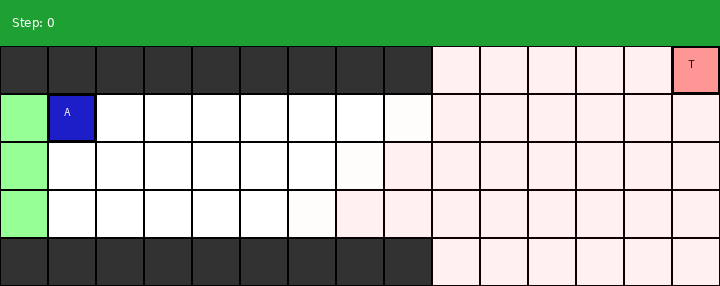

In [52]:
# Visualize & safe gif 
gif_path = "heter.gif"
imageio.mimsave(gif_path, frames, fps=10)
print(f"Saved {gif_path}")
ip.display(ip.Image(gif_path))

In [53]:
print(history['M_action'].count('Down')/len(history['M_action']))
print(history['M_action'].count('Up')/len(history['M_action']))
print(history['M_action'].count('Right')/len(history['M_action']))
print(history['M_action'].count('Left')/len(history['M_action']))
print(history['M_action'].count('Stay')/len(history['M_action']))

0.366
0.362
0.104
0.09
0.078


In [54]:
import pickle

with open('logs.pkl', 'wb') as f:
    pickle.dump(history, f)

# load
# with open('logs.pkl', 'rb') as f:
#     loaded_history = pickle.load(f)